In [ ]:
import h5py
import pandas as pd
import numpy as np
file_path = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Germany\2018_data_15min.hdf5"

with h5py.File(file_path, "r") as f:
    def print_structure(name, obj):
        print(name)
    f.visititems(print_structure)

MISC
MISC/ES1
MISC/ES1/TRANSFORMER
MISC/ES1/TRANSFORMER/table
MISC/PV1
MISC/PV1/PV
MISC/PV1/PV/INVERTER
MISC/PV1/PV/INVERTER/EAST
MISC/PV1/PV/INVERTER/EAST/table
MISC/PV1/PV/INVERTER/SOUTH
MISC/PV1/PV/INVERTER/SOUTH/table
MISC/PV1/PV/INVERTER/WEST
MISC/PV1/PV/INVERTER/WEST/table
NO_PV
NO_PV/SFH10
NO_PV/SFH10/HEATPUMP
NO_PV/SFH10/HEATPUMP/table
NO_PV/SFH10/HOUSEHOLD
NO_PV/SFH10/HOUSEHOLD/table
NO_PV/SFH11
NO_PV/SFH11/HEATPUMP
NO_PV/SFH11/HEATPUMP/table
NO_PV/SFH11/HOUSEHOLD
NO_PV/SFH11/HOUSEHOLD/table
NO_PV/SFH12
NO_PV/SFH12/HEATPUMP
NO_PV/SFH12/HEATPUMP/table
NO_PV/SFH12/HOUSEHOLD
NO_PV/SFH12/HOUSEHOLD/table
NO_PV/SFH14
NO_PV/SFH14/HEATPUMP
NO_PV/SFH14/HEATPUMP/table
NO_PV/SFH14/HOUSEHOLD
NO_PV/SFH14/HOUSEHOLD/table
NO_PV/SFH16
NO_PV/SFH16/HEATPUMP
NO_PV/SFH16/HEATPUMP/table
NO_PV/SFH16/HOUSEHOLD
NO_PV/SFH16/HOUSEHOLD/table
NO_PV/SFH17
NO_PV/SFH17/HEATPUMP
NO_PV/SFH17/HEATPUMP/table
NO_PV/SFH17/HOUSEHOLD
NO_PV/SFH17/HOUSEHOLD/table
NO_PV/SFH18
NO_PV/SFH18/HEATPUMP
NO_PV/SFH18/HEATPUMP/

In [ ]:
import h5py
import pandas as pd
import numpy as np


def load_germany_year_with_hp(file_path):
    
    house_data = {}
    
    with h5py.File(file_path, "r") as f:
        
        def collect(group_name):
            if group_name not in f:
                return
            
            group = f[group_name]
            
            for house in group.keys():
                
                # ---------- household ----------
                path_house = f"{group_name}/{house}/HOUSEHOLD/table"
                
                if path_house not in f:
                    continue
                
                ds_house = f[path_house]
                P_house = ds_house["P_TOT"]
                
                if np.isnan(P_house).all():
                    continue
                
                ts = pd.to_datetime(ds_house["index"], unit="s", utc=True)
                
                s_house = pd.Series(P_house, index=ts)
                
                
                # ---------- heat pump ----------
                path_hp = f"{group_name}/{house}/HEATPUMP/table"
                
                if path_hp in f:
                    ds_hp = f[path_hp]
                    P_hp = ds_hp["P_TOT"]
                    
                    s_hp = pd.Series(P_hp, index=ts)
                    
                    # add heat pump consumption
                    s_total = s_house.add(s_hp, fill_value=0)
                
                else:
                    s_total = s_house
                
                s_total.name = house
                
                house_data[house] = s_total
        
        collect("NO_PV")
        collect("WITH_PV")
    
    df = pd.concat(house_data.values(), axis=1)
    
    # align to 15-min grid
    df = df.resample("15min").mean()
    
    return df

In [ ]:
fp18 = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Germany\2018_data_15min.hdf5"
fp19 = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Germany\2019_data_15min.hdf5"
fp20 = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Germany\2020_data_15min.hdf5"

df_2018 = load_germany_year_with_hp(fp18)
df_2019 = load_germany_year_with_hp(fp19)
df_2020 = load_germany_year_with_hp(fp20)

In [ ]:
df_all = pd.concat([df_2018, df_2019, df_2020]).sort_index()

In [ ]:
print(df_2018.shape)
print(df_2018.describe())

(35040, 38)
              SFH10         SFH11         SFH12         SFH14         SFH16  \
count  23005.000000  23004.000000  22629.000000  22608.000000  22525.000000   
mean    1256.762324    682.739478    493.003061   1117.346682    425.734409   
std     1381.454250   1046.996914    827.711275   2217.520445    648.753292   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%      495.062000    163.247000    130.137889    112.715972     95.941223   
50%      812.264334    225.569111    175.635555    206.637722    162.345556   
75%     1381.409549    666.851613    307.813111    570.911555    461.980445   
max    13287.060108   9347.087706   7985.823863  13052.200943  14315.716367   

              SFH17         SFH18         SFH19         SFH20         SFH21  \
count  20450.000000  22430.000000  22411.000000   6920.000000  14951.000000   
mean    1183.722756    501.468582    486.264162   2623.363898    794.632103   
std     1006.444976    665.337780    66

In [ ]:
df_all

,SFH10,SFH11,SFH12,SFH14,SFH16,SFH17,SFH18,SFH19,SFH20,SFH21,...,SFH40,SFH5,SFH6,SFH7,SFH8,SFH9,SFH13,SFH15,SFH26,SFH33
2018-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 22:45:00+00:00,NaN,1660.935337,2671.215778,2845.234555,1331.093222,3218.329219,901.888887,405.400444,1033.014223,1990.478131,...,285.218445,1027.835558,2577.048112,1485.699667,NaN,3419.542446,586.091889,2737.100216,60.863889,847.135224
2020-12-31 23:00:00+00:00,NaN,1940.249954,511.710007,846.879974,369.019997,858.469986,399.869991,384.460009,382.130001,2339.110092,...,222.479996,1043.950012,250.100006,2725.609985,NaN,1192.230011,587.710007,2775.329971,61.070002,635.550018
2020-12-31 23:15:00+00:00,NaN,1940.249954,511.710007,846.879974,369.019997,858.469986,399.869991,384.460009,382.130001,2339.110092,...,222.479996,1043.950012,250.100006,2725.609985,NaN,1192.230011,587.710007,2775.329971,61.070002,635.550018
2020-12-31 23:30:00+00:00,NaN,1940.249954,511.710007,846.879974,369.019997,858.469986,399.869991,384.460009,382.130001,2339.110092,...,222.479996,1043.950012,250.100006,2725.609985,NaN,1192.230011,587.710007,2775.329971,61.070002,635.550018


In [ ]:
total_points = len(df_all)

availability = df_all.notna().sum() / total_points * 100

availability = availability.sort_values(ascending=False)

print(availability)

SFH3     88.848654
SFH4     88.830596
SFH9     88.562576
SFH12    88.204266
SFH14    88.184307
SFH16    88.105421
SFH18    88.015131
SFH19    87.997073
SFH26    87.472438
SFH27    87.466735
SFH28    87.448677
SFH22    87.381197
SFH29    87.381197
SFH30    87.366940
SFH32    87.071358
SFH33    86.916439
SFH5     86.768172
SFH34    86.650319
SFH36    86.633212
SFH10    85.186664
SFH31    84.041401
SFH23    82.737416
SFH7     82.158607
SFH21    80.906896
SFH38    79.784443
SFH39    78.895795
SFH11    77.903551
SFH20    73.274027
SFH35    68.245324
SFH8     66.910926
SFH13    66.815884
SFH37    66.183850
SFH15    65.778969
SFH40    58.224985
SFH17    47.906212
SFH25    47.615382
SFH6     39.048244
SFH24     8.395111
dtype: float64


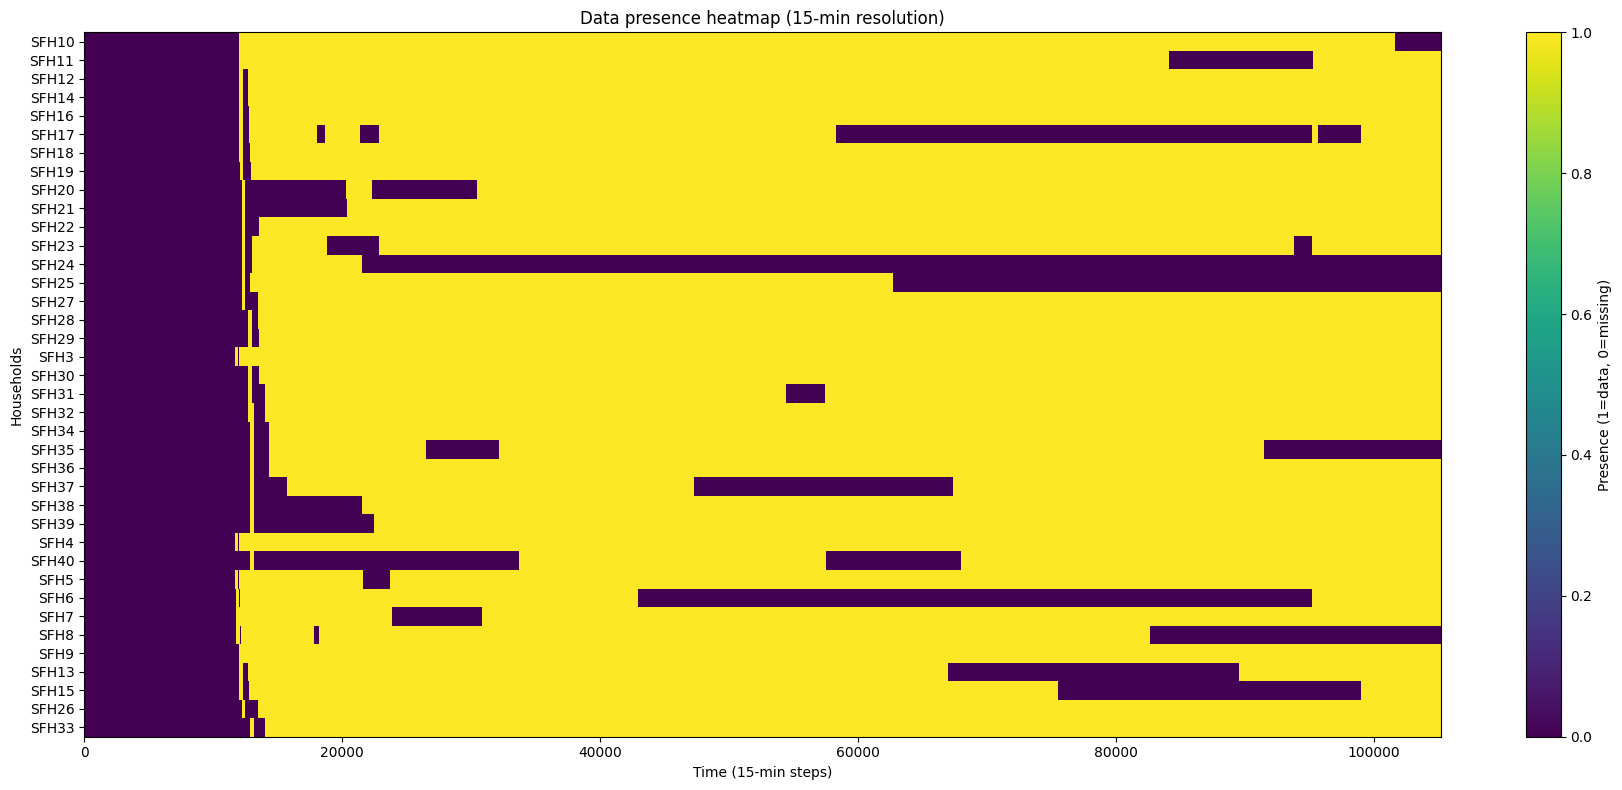

In [27]:
import matplotlib.pyplot as plt

presence = df_all.notna().astype(int)   # (time x households)

plt.figure(figsize=(18, 8))
plt.imshow(
    presence.T,            # households on y, time on x
    aspect="auto",
    interpolation="none"
)

plt.yticks(range(len(presence.columns)), presence.columns)
plt.colorbar(label="Presence (1=data, 0=missing)")
plt.xlabel("Time (15-min steps)")
plt.ylabel("Households")
plt.title("Data presence heatmap (15-min resolution)")

plt.tight_layout()
plt.show()

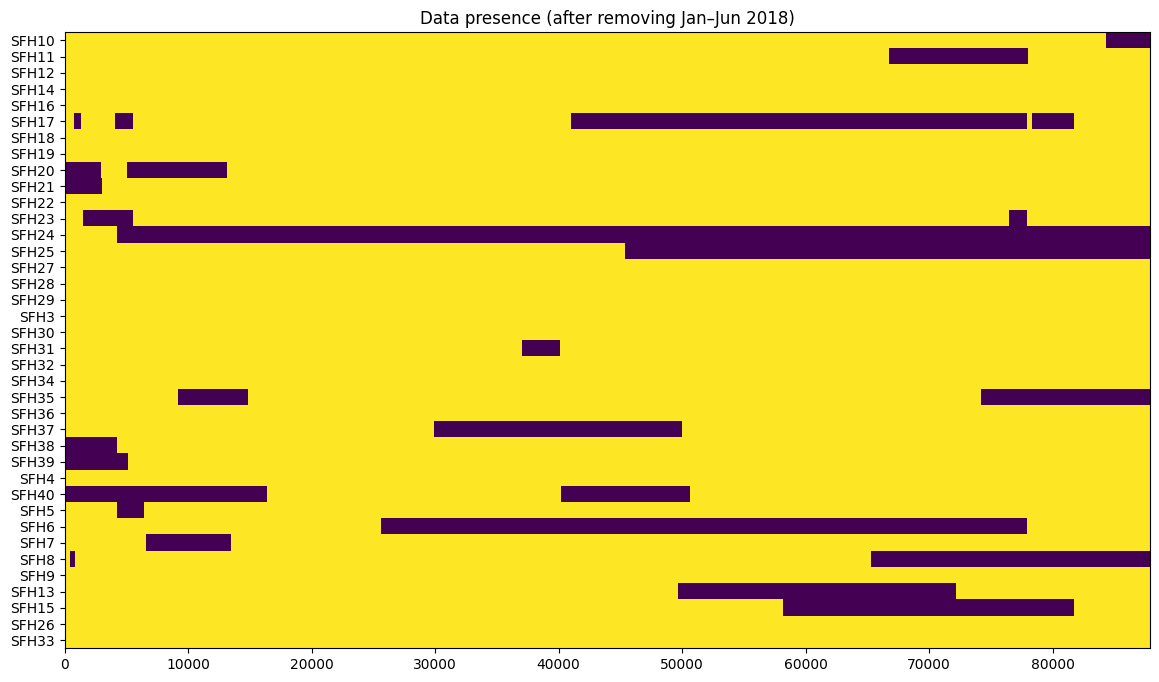

In [29]:
df_clean = df_all.loc["2018-07-01":]
presence = df_clean.notna().astype(int)

plt.figure(figsize=(14,8))
plt.imshow(presence.T, aspect="auto", interpolation="none")
plt.yticks(range(len(presence.columns)), presence.columns)
plt.title("Data presence (after removing Jan–Jun 2018)")
plt.show()

In [30]:
coverage = df_clean.notna().mean() * 100

coverage = coverage.sort_values(ascending=False)

print(coverage)

SFH14    100.000000
SFH12    100.000000
SFH16    100.000000
SFH22    100.000000
SFH19    100.000000
SFH18    100.000000
SFH34    100.000000
SFH32    100.000000
SFH4     100.000000
SFH30    100.000000
SFH3     100.000000
SFH29    100.000000
SFH28    100.000000
SFH27    100.000000
SFH9     100.000000
SFH33    100.000000
SFH36    100.000000
SFH26    100.000000
SFH5      97.544399
SFH21     96.579007
SFH31     96.544854
SFH10     95.957423
SFH38     95.237933
SFH39     94.173497
SFH23     93.793260
SFH7      92.110656
SFH20     87.438525
SFH11     87.234745
SFH35     77.965619
SFH37     77.127732
SFH13     74.390938
SFH8      73.852459
SFH15     73.251366
SFH40     69.413707
SFH17     51.855647
SFH25     51.599499
SFH6      40.464481
SFH24      4.755237
dtype: float64


In [31]:
threshold = 80

valid_houses = coverage[coverage >= threshold].index

df_filtered = df_clean[valid_houses]

In [32]:
removed_houses = coverage[coverage < threshold]

print("Removed households (<80% coverage):")
print(removed_houses)

Removed households (<80% coverage):
SFH35    77.965619
SFH37    77.127732
SFH13    74.390938
SFH8     73.852459
SFH15    73.251366
SFH40    69.413707
SFH17    51.855647
SFH25    51.599499
SFH6     40.464481
SFH24     4.755237
dtype: float64


In [33]:
print("Remaining households:", df_filtered.shape[1])
print("Time steps:", df_filtered.shape[0])

Remaining households: 28
Time steps: 87840


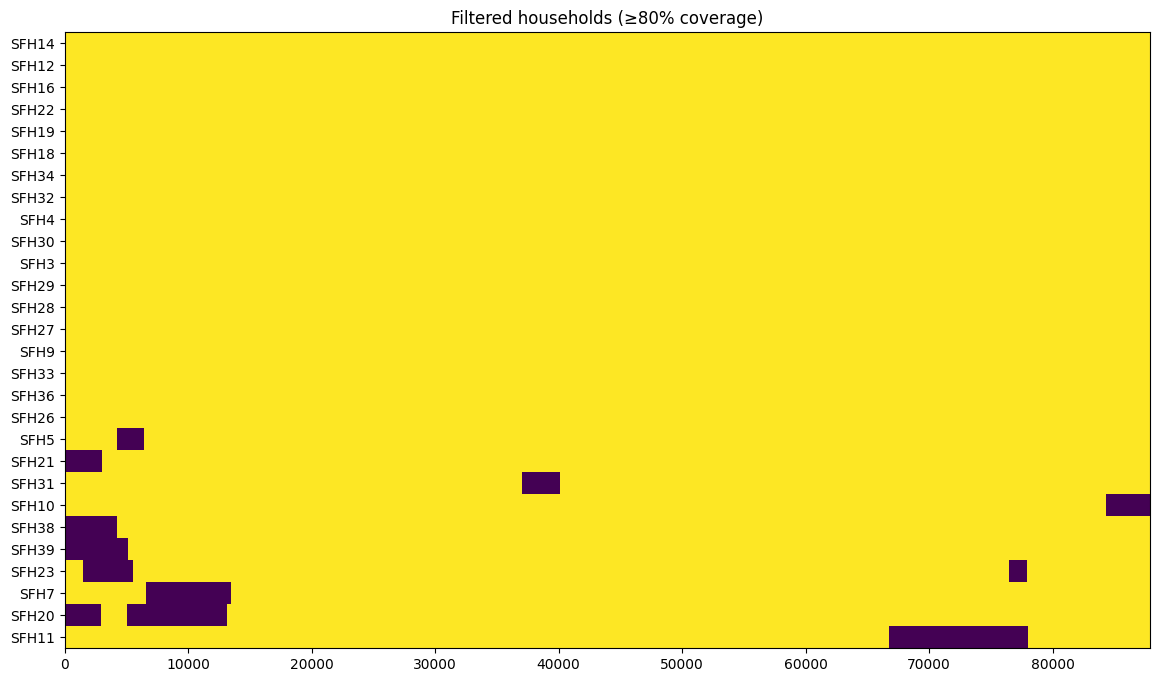

In [34]:
presence = df_filtered.notna().astype(int)

plt.figure(figsize=(14,8))
plt.imshow(presence.T, aspect="auto", interpolation="none")
plt.yticks(range(len(presence.columns)), presence.columns)
plt.title("Filtered households (≥80% coverage)")
plt.show()

# lets read the weather data

In [ ]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# --- Get start/end from power_selected ---
power_selected.index = pd.to_datetime(power_selected.index)

start_ts = power_selected.index.min()
end_ts   = power_selected.index.max()

start_date = start_ts.strftime("%Y-%m-%d")
end_date   = end_ts.strftime("%Y-%m-%d")

print("Power period:", start_ts, "→", end_ts)
print("Weather API dates:", start_date, "→", end_date)

# --- Setup client (cache forever is fine; you can also use expire_after=3600) ---
cache_session = requests_cache.CachedSession(".cache", expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# --- Historical archive endpoint ---
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 32.6587,
    "longitude": -16.9218,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "precipitation",
        "direct_radiation",
    ],
    "timezone": "UTC",
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# --- Parse hourly data (order must match params["hourly"]) ---
hourly = response.Hourly()

hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(2).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(3).ValuesAsNumpy()
hourly_direct_radiation = hourly.Variables(4).ValuesAsNumpy()

hourly_index = pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left",
)

weather_hourly = pd.DataFrame(
    {
        "temperature_2m": hourly_temperature_2m,
        "relative_humidity_2m": hourly_relative_humidity_2m,
        "wind_speed_10m": hourly_wind_speed_10m,
        "precipitation": hourly_precipitation,
        "direct_radiation": hourly_direct_radiation,
    },
    index=hourly_index,
)

print("\nWeather hourly head:\n", weather_hourly.head())
print("\nWeather hourly tail:\n", weather_hourly.tail())




# --- Convert to 15-min to match power_selected timestamps ---
weather_15min = weather_hourly.resample("15min").interpolate("time")

power_selected.index = power_selected.index.tz_localize("UTC")

weather_15min_aligned = weather_15min.reindex(power_selected.index)


print("\nWeather 15-min aligned shape:", weather_15min_aligned.shape)

In [ ]:
data_merged = power_selected.join(weather_15min_aligned, how="left")

print(data_merged.shape)
data_merged.head()

In [ ]:
data_merged

In [ ]:
data_merged.index = data_merged.index.tz_convert(None)

In [ ]:
data_merged

# imputer

In [ ]:
import os
import shutil
from typing import List, Tuple, Optional
from pathlib import Path
from typing import List
import pandas as pd
import lightgbm

def imputer(df, target_columns=None, lgbm_params=None):
    """
    Impute missing values in a time-series Series or DataFrame.
    Here we apply a linearly interpolation on 2 consecutive NaNs or fewer.
    If there is a larger chunk of NaNs then we use a LightGBM regressor to fill in longer missing intervals.

    Parameters
    ----------
    df : pd.Series or pd.DataFrame
        A pandas Series or DataFrame with a DatetimeIndex.
    target_columns : list or None
        Which columns to impute. If None, all columns with NaNs will be imputed.
        (Ignored if df is a Series, because there's only one column.)
    lgbm_params : dict or None
        Parameters for the LGBMRegressor. If None, defaults are used.

    Returns
    -------
    pd.Series or pd.DataFrame
        The same type as `df`, with missing values imputed.
    """
    # Check if input is a Series
    was_series = False
    original_name = None
    if isinstance(df, pd.Series):
        was_series = True
        original_name = df.name if df.name is not None else "value"
        df = df.to_frame(name=original_name)
    
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame/Series must have a DatetimeIndex.")
    
    # Identify columns needing imputation
    if target_columns is None:
        target_columns = [col for col in df.columns if df[col].isna().any()]
    
    # First pass: linearly interpolate small gaps (<= 2 consecutive NaNs)
    for col in target_columns:
        small_gaps = df[col].isna().astype(int).groupby(df[col].notna().cumsum()).sum()
        if any((small_gaps <= 2) & (small_gaps > 0)):
            print(f"Column '{col}' has small gaps (<= 2 consecutive NaNs).")
    df[target_columns] = df[target_columns].interpolate(method='linear', limit=2)
    
    # Default LightGBM parameters if none provided
    if lgbm_params is None:
        lgbm_params = {
            'n_estimators': 500,
            'learning_rate': 0.1,
            'random_state': 42
        }

    # Create time-based features
    global_time_features = pd.DataFrame(index=df.index)
    global_time_features['minute'] = df.index.minute
    global_time_features['hour'] = df.index.hour
    global_time_features['day'] = df.index.day
    global_time_features['dayofweek'] = df.index.dayofweek
    global_time_features['month'] = df.index.month

    #LightGBM for larger gaps
    for target in target_columns:
        # Check if there are still missing values after small-gap interpolation
        if not df[target].isna().any():
            continue 
        print(f"Column '{target}' has large gaps (> 2 consecutive NaNs).")

        # we only train the model on rows for which the target column has non‐missing values
        not_null_mask = df[target].notna()
        y_train = df.loc[not_null_mask, target]

        # Build training features
        other_cols = df.columns.difference([target])
        X_train = pd.concat([df.loc[not_null_mask, other_cols],
                             global_time_features.loc[not_null_mask]], axis=1)

        # Train LightGBM
        model = lightgbm.LGBMRegressor(**lgbm_params,verbose=-1)
        model.fit(X_train, y_train)

        # Predict for the missing rows
        null_mask = df[target].isna()
        if null_mask.any():
            X_missing = pd.concat([df.loc[null_mask, other_cols],
                                   global_time_features.loc[null_mask]], axis=1)
            df.loc[null_mask, target] = model.predict(X_missing)

    if was_series:
        col_name = df.columns[0]
        df_series = df[col_name]
        df_series.name = original_name
        return df_series

    return df

def feature_correlation_sorter_and_remover(df: pd.DataFrame, target: str, threshold: float = 0.1) -> pd.Series:
    """
    This function sorts the features based on their correlation with the target 
    and removes the ones that are below the threshold.
    
    Parameters:
        df (pd.DataFrame): The DataFrame with the features and the target column.
        target (str): The name of the target column.
        threshold (float): The threshold for the correlation (default is 0.1).
    
    Returns:
        pd.Series: The features (rows) that are above the threshold and their correlation with the target.
    """
    # Compute correlation with the target column
    correlation_with_target = df.corr(method="pearson")[target].abs()
    
    # Sort features by correlation values in descending order
    sorted_features = correlation_with_target.sort_values(ascending=False)
    
    # Filter features based on the threshold
    filtered_features = sorted_features[sorted_features >= threshold]

    # Return the filtered and sorted features with their correlations
    return filtered_features.drop(target, errors='ignore')


def list_creator_flagger(
    df: pd.DataFrame, 
    substrings: Optional[List[str]] = None
) -> Tuple[List[str], List[str]]:
    """
    Separates DataFrame columns into two lists: those containing specified substrings 
    and those that do not.

    Parameters:
        df (pd.DataFrame): The DataFrame with the features.
        substrings (List[str], optional): The list of substrings to search for in column names.
            Default is ['flag', 'cos', 'sin', 'day_of_week', 'day_of_month', 'weekend', 
                       'days_in_month', 'hour', 'minute'].

    Returns:
        - non_flag_columns (List[str]): Columns that do not contain the specified substrings.
        - flag_columns (List[str]): Columns that contain the specified substrings.
    """
    if substrings is None:
        substrings = [
            'flag', 'cos', 'sin', 'day_of_week', 'day_of_month', 
            'weekend', 'days_in_month', 'hour', 'minute'
        ]

    flag_columns = [col for col in df.columns if any(substring in col for substring in substrings)]

    if not flag_columns:
        print("No columns with the specified substrings found.")
        return [], []

    non_flag_columns = [col for col in df.columns if col not in flag_columns]

    return non_flag_columns, flag_columns

def empty_folder(folder: str) -> None:
    """
    Empties a folder by deleting all its contents. If the folder does not exist, it creates it.

    Args:
        folder (str): The path to the folder to be emptied.
    """
    # Get the absolute path of the folder
    absolute_folder_path = os.path.abspath(folder)
    print(f"Attempting to empty folder: {absolute_folder_path}")
    
    # Check if the directory exists; create it if not
    if not os.path.exists(absolute_folder_path):
        os.makedirs(absolute_folder_path)  # Creates the folder if it doesn't exist
        print(f"Folder did not exist and was created: {absolute_folder_path}")
        return  # Exit after creating, no need to empty

    print(f"Folder exists and will be emptied: {absolute_folder_path}")
        
    # Iterate over the items in the directory
    for item in os.listdir(absolute_folder_path):
        item_path = os.path.join(absolute_folder_path, item)
        print(f"Processing item: {item_path}")
        
        # Delete file or directory
        try:
            if os.path.isfile(item_path):
                os.remove(item_path)
                print(f"Deleted file: {item_path}")
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
                print(f"Deleted directory: {item_path}")
        except Exception as e:
            print(f"Error deleting {item_path}: {e}")
    
    print(f"The folder '{folder}' has been emptied.")

def save_best_params_to_csv(study, path: str, hours: int) -> None:
    """
    Save the best parameters from an Optuna study to a CSV file in the 'models' directory.
    Every time the function is called, it appends the new data to the existing CSV file.

    Args:
        study: Optuna study object containing the best parameters and trial results.
        path (str): Base path where the 'models' folder is located.
        hours (int): Multiplication factor for 'hours_in'.
    """
    # Extract best parameters and additional information
    best_params = study.best_params.copy()
    best_params["mse"] = study.best_trial.value
    best_params["trials"] = len(study.trials)
    best_params['hours_in'] *= hours  # Convert back to points

    # Handle `fc_layers` (convert to string for saving)
    fc_layers = [
        best_params.pop(f"fc_layer_{i+1}", None) for i in range(best_params.get("n_layers", 0))
    ]
    best_params["fc_layers"] = ",".join(map(str, fc_layers))  # Save as comma-separated string

    # Define the column names
    columns = [
        'hours_in', 'hours_out', 'suggested_hidden_dim', 'n_rnn_layers',
        'dropout', 'lr','fc_layers', 'mse', 'trials'
    ]

    # Create a DataFrame for the best parameters
    best_params_df = pd.DataFrame([best_params])

    # Define the file path
    target_dir = Path(path) / 'models'
    hyper_params_filepath = target_dir / "hyper_params_df.csv"
    print(f"Saving to file: {hyper_params_filepath}")

    # Check if the file exists
    if hyper_params_filepath.is_file():
        # Read the existing file
        existing_df = pd.read_csv(hyper_params_filepath)
        print("File exists. Appending data.")
        
        if set(columns).issubset(existing_df.columns):
            # Append new data to existing DataFrame
            updated_df = pd.concat([existing_df, best_params_df], ignore_index=True)
        else:
            print("Warning: CSV columns do not match expected columns. Columns will be reset.")
            # Create a new DataFrame with the correct columns
            updated_df = pd.DataFrame(columns=columns)
            updated_df = pd.concat([updated_df, best_params_df], ignore_index=True)
    else:
        print("File does not exist. Creating new file.")
        # Create a new DataFrame with the correct columns
        updated_df = pd.DataFrame(columns=columns)
        updated_df = pd.concat([updated_df, best_params_df], ignore_index=True)

    # Save the DataFrame to CSV
    updated_df.to_csv(hyper_params_filepath, index=False)
    print("Data saved successfully.")
    
def read_hyper_params(path: str) -> dict:
    """
    Reads the hyperparameters from the CSV file and returns the last line as a dictionary.

    Args:
        path (str): The path to the folder where the models are stored.

    Returns:
        dict: The last line of the CSV file as a dictionary.
    
    Raises:
        ValueError: If the CSV file is empty.
    """
    # Define the path to the CSV file
    path_csv = Path(path) / "models" / "hyper_params_df.csv"
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(path_csv)
    
    if df.empty:
        raise ValueError("The CSV file is empty.")
    
    # Get the last row as a Series
    last_line = df.iloc[-1]
    
    # Convert the Series to a dictionary
    last_line_dict = last_line.to_dict()
    
    # Process `fc_layers` (convert back to a list of integers)
    if "fc_layers" in last_line_dict:
        last_line_dict["fc_layers"] = list(map(int, last_line_dict["fc_layers"].split(",")))

    # Define the keys that should not be converted to int
    exclude_from_int_conversion = {"dropout", "lr", "fc_layers"}
    
    # Process the dictionary
    processed_dict = {}
    for key, value in last_line_dict.items():
        if key in exclude_from_int_conversion:
            processed_dict[key] = value
        else:
            try:
                processed_dict[key] = int(value)
            except (ValueError, TypeError):
                processed_dict[key] = value
    
    return processed_dict

def separate_past_and_future_features(ordered_features_list):
    """
    Separates features into past and future covariates based on specific conditions.

    Args:
        ordered_features_list (list of str): List of feature names in the desired order.

    Returns:
        tuple: A tuple containing two lists:
            - past_covariates (list of str): Features considered as past covariates.
            - future_covariates (list of str): Features considered as future covariates.
    """
    past_covariates = []
    future_covariates = []
    
    future_condition_strings = [
        "sin", "cos", "hour", "flag", "day", "month", "week",
        "weekend", "day_of_week", "day_of_month", "days_in_month",
        "minute"
    ]
    
    for feature in ordered_features_list:
        if any(condition_string in feature for condition_string in future_condition_strings):
            future_covariates.append(feature)
        else:
            past_covariates.append(feature)
    
    return past_covariates, future_covariates



My imputer() uses other columns as features. If those other columns still contain NaNs in the rows you’re predicting, LightGBM may error or behave badly. So it’s best to impute in a safe order:

impute weather first (almost no gaps)

then impute households using weather + time features (and optionally other homes)

In [ ]:
home_cols = [c for c in data_merged.columns if c.startswith("home_")]
weather_cols = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "precipitation", "direct_radiation"]

data_imp = data_merged.copy()

# Impute weather only first
data_imp[weather_cols] = imputer(
    data_imp[weather_cols],
    target_columns=weather_cols
)

data_imp = data_merged.copy()

# Impute weather only first
data_imp[weather_cols] = imputer(
    data_imp[weather_cols],
    target_columns=weather_cols
)

data_imp_homes = data_imp.copy()

for col in home_cols:
    print(f"\nImputing {col} ...")
    tmp = pd.concat([data_imp_homes[[col]], data_imp_homes[weather_cols]], axis=1)
    tmp_imputed = imputer(tmp, target_columns=[col])
    data_imp_homes[col] = tmp_imputed[col]
    
data_imp = data_imp_homes

In [ ]:
print("Missing values after imputation (%):")
print((data_imp.isna().mean() * 100).sort_values(ascending=False).head(15))

In [ ]:
data_imp["home_15"][:1000].plot()

In [ ]:
data_imp

In [ ]:
negative_per_house = (data_imp < 0).sum()
print(negative_per_house)

In [ ]:
neg_positions = (
    data_imp[data_imp < 0]
    .stack()
    .reset_index()
)

neg_positions.columns = ["timestamp", "house", "value"]

print(neg_positions)

In [ ]:
data_imp[data_imp < 0] = 0

In [ ]:
neg_positions = (
    data_imp[data_imp < 0]
    .stack()
    .reset_index()
)

neg_positions.columns = ["timestamp", "house", "value"]

print(neg_positions)

In [ ]:
data_imp

In [ ]:
output_path = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Portugal.csv"

data_imp.index.name = "timestamp"   # optional but good practice
data_imp.to_csv(output_path, index=True)

print("Saved to:", output_path)